# AI Coach - Refined Approach (Auto-Labeling & Full Classification)

This notebook documents the original approach to the AI Coach project.


In [ ]:

%pip -q install --upgrade pip
%pip -q install -r requirements.txt || true

import os
from pathlib import Path
import sys
from dotenv import load_dotenv
load_dotenv()

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
print('Project root:', PROJECT_ROOT)



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Project root: /Users/user/MScAI_Thesis


In [ ]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
import joblib
from collections import deque
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import kagglehub
import subprocess
import importlib

from ai_coach import pose, features, per_rep_features, coach, classifier, exercises
importlib.reload(pose)
importlib.reload(features)
importlib.reload(per_rep_features)
importlib.reload(coach)
importlib.reload(classifier)
importlib.reload(exercises)

from ai_coach.pose import PoseEstimator, compute_basic_angles
from ai_coach.features import extract_feature_vector, FEATURE_ORDER
from ai_coach.per_rep_features import RepAggregate, SQUAT_REP_FEATURES
from ai_coach.coach import HybridSquatCoach
from ai_coach.classifier import ExerciseClassifier
from ai_coach.exercises import SquatAdvisor, SimpleRepCounter


VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv'}

print("Common libraries and project modules imported and reloaded.")



Common libraries and project modules imported and reloaded.


In [ ]:
# Download Kaggle dataset
DATASET_ID = "hasyimabdillah/workoutfitness-video"
kaggle_path = kagglehub.dataset_download(DATASET_ID)
print('Kaggle dataset path:', kaggle_path)


Kaggle dataset path: /Users/user/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5


In [ ]:
YOUTUBE_URLS = [
    "https://www.youtube.com/shorts/PPmvh7gBTi0", "https://www.youtube.com/shorts/iZTxa8NJH2g",
    "https://www.youtube.com/shorts/eFEVKmp3M4g", "https://www.youtube.com/shorts/gzd9gcsr4Bs",
    "https://www.youtube.com/shorts/SLOkdLLWj8A", "https://www.youtube.com/shorts/tCmyswyIAbc",
    "https://www.youtube.com/shorts/1wON5Zfoagw", "https://www.youtube.com/shorts/gslEzVggur8",
    "https://www.youtube.com/shorts/T6id8FuUcao", "https://www.youtube.com/shorts/Qj0UtfzpWGM",
    "https://www.youtube.com/shorts/Lq9bf_QUSns", "https://www.youtube.com/shorts/baCXyqhmuN4",
    "https://www.youtube.com/shorts/0nwbM25FSFQ", "https://www.youtube.com/shorts/iKCJCydYYrE",
    "https://www.youtube.com/shorts/o_ui3g0MmxY", "https://www.youtube.com/shorts/pEwUg6IhW7k",
    "https://www.youtube.com/shorts/n_xLyzPEX7A", "https://www.youtube.com/shorts/aR9rwprpZ9Q",
    "https://www.youtube.com/shorts/ulVUdTjSLKU", "https://www.youtube.com/shorts/Xt5TQCPbj5c",
    "https://www.youtube.com/shorts/8wNgyh13rFc", "https://www.youtube.com/shorts/oRIV2gfKRnE",
    "https://www.youtube.com/shorts/6Xi_M8q8-4k", "https://www.youtube.com/shorts/j-00GE7AnQg",
    "https://www.youtube.com/shorts/Xmgzf6Tnof8", "https://www.youtube.com/shorts/XmwDjXKWhRE",
    "https://www.youtube.com/shorts/xNwpvDuZJ3k", "https://www.youtube.com/shorts/_TchJLlBO-4",
    "https://www.youtube.com/shorts/vfKwjT5-86k", "https://www.youtube.com/shorts/w8ZhgecdIAM",
    "https://www.youtube.com/shorts/zBQB3swVUjU", "https://www.youtube.com/watch?v=WbKT5b8ydmM",
    "https://www.youtube.com/shorts/AIZ8q1qruKw", "https://www.youtube.com/shorts/F1k_pqn6KzE",
    "https://www.youtube.com/shorts/rRPIHpTJJtM", "https://www.youtube.com/shorts/-spDMULS9ZU",
    "https://www.youtube.com/shorts/cNjI4dQCKNE", "https://www.youtube.com/shorts/bNE5syFeGWk",
    "https://www.youtube.com/shorts/D6Buq8pmqDk", "https://www.youtube.com/shorts/FG5PgUd_NKI",
    "https://www.youtube.com/shorts/HZilSL4ZNvQ", "https://www.youtube.com/shorts/Xg0X244D9Vs",
    "https://www.youtube.com/shorts/QY1R4ycPyR8", "https://www.youtube.com/shorts/9Q4QJDFLHkM",
    "https://www.youtube.com/shorts/EHHWdLl8wCc", "https://www.youtube.com/shorts/I7Nk1RMtcLs",
    "https://www.youtube.com/shorts/-yBkaEi4l3o", "https://www.youtube.com/watch?v=dZykAUFxSCE",
    "https://www.youtube.com/shorts/tXu-RpwF-NU", "https://www.youtube.com/shorts/hd5uyrJvrx0",
    "https://www.youtube.com/shorts/THiQpitHxqw", "https://www.youtube.com/shorts/L4elVVYmQrw",
    "https://www.youtube.com/shorts/i9MFFBVUeRU", "https://www.youtube.com/shorts/G660RDFPeQ4",
    "https://www.youtube.com/shorts/okj7OgxbJIU", "https://www.youtube.com/shorts/I4kkQLiTeiI",
    "https://www.youtube.com/shorts/rWo308CxbUQ", "https://www.youtube.com/shorts/Qwpb2MfNMRE",
    "https://www.youtube.com/shorts/jDlVaog-_io", "https://www.youtube.com/shorts/mPnR3l1153Q",
    "https://www.youtube.com/shorts/JIzl09cRcVc", "https://www.youtube.com/shorts/CspRAoM6ZKA",
    "https://www.youtube.com/shorts/HxtOrszwyk0", "https://www.youtube.com/shorts/zn7bncZgKh4",
    "https://www.youtube.com/shorts/300DXrIPIuE", "https://www.youtube.com/shorts/rpza2Mxpi2M",
    "https://www.youtube.com/shorts/4tPuVziek5I","https://www.youtube.com/shorts/_wi9qqg2N7g",
    "https://www.youtube.com/shorts/s4r7UUPc2nY","https://www.youtube.com/shorts/FfESA-avdAw",
    "https://www.youtube.com/shorts/2CHqxQILLmg","https://www.youtube.com/watch?v=dkzgOJdAo_Y",
    "https://www.youtube.com/shorts/0CrRurum5G8","https://www.youtube.com/shorts/OQvG1R4ZViQ",
    "https://www.youtube.com/shorts/eyjVqIzBNns","https://www.youtube.com/watch?v=0y7IOTZJ3cA",
    "https://www.youtube.com/shorts/xb6HeJrGJ7c","https://www.youtube.com/shorts/tuK-QIWjad8",
    "https://www.youtube.com/watch?v=H013MrjgC1M","https://www.youtube.com/shorts/bC1JV4iSsjA",
    "https://www.youtube.com/shorts/6JgfAxa-Was","https://www.youtube.com/shorts/vcqJoEXv8pA",
    "https://www.youtube.com/shorts/uHehIWMtL4k","https://www.youtube.com/shorts/D4kOfkz0xOE",
    "https://www.youtube.com/watch?v=OgDVFz0Wwsw","https://www.youtube.com/watch?v=sBq5rpF3wrc",
    "https://www.youtube.com/shorts/UMluHb2EUKw","https://www.youtube.com/shorts/DaWGKLr8FWA",
    "https://www.youtube.com/shorts/3PgoOmihVJM","https://www.youtube.com/shorts/mlHfHusKruY",
    "https://www.youtube.com/shorts/3cmYI4Nyoss","https://www.youtube.com/shorts/qvKGq1ilobk",
    "https://www.youtube.com/shorts/dzkzNql14Yw","https://www.youtube.com/shorts/G4uFXQfx7A8",
    "https://www.youtube.com/shorts/pU6yWcyg_u4","https://www.youtube.com/watch?v=26n6AU0qIW0",
    "https://www.youtube.com/shorts/lRChK0vEqzM","https://www.youtube.com/shorts/k0D4JnCwU7k",
    "https://www.youtube.com/shorts/8a2UTjw02FU","https://www.youtube.com/shorts/MOTq_zdyZsU",
    "https://www.youtube.com/shorts/wUYZCc9mscE","https://www.youtube.com/shorts/TfvyhEH8Huo",
    "https://www.youtube.com/shorts/ZUzA5dO49C4","https://www.youtube.com/shorts/CspRAoM6ZKA",
    "https://www.youtube.com/shorts/2fugnJv5PhU",

]
out_dir = Path("data/youtube_videos")
out_dir.mkdir(parents=True, exist_ok=True)
if YOUTUBE_URLS:
    for url in YOUTUBE_URLS:
        try:
            subprocess.run(
                ["yt-dlp", "-f", "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best",
                 "--merge-output-format", "mp4", "-o", str(out_dir / "%(title)s.%(ext)s"), url],
                check=True, capture_output=True)
        except subprocess.CalledProcessError as e:
            print(f"Failed to download {url}: {e.stderr.decode()}")
    print(f"YouTube download complete. Downloaded videos to {out_dir}")
else:
    print("No YouTube URLs provided; skipping download.")



YouTube download complete. Downloaded videos to data/youtube_videos


### Auto-Labeling and Multi-Class Dataset Creation
This section uses a rule-based algorithm to label each rep from the Kaggle and YouTube videos into one of four classes: `good`, `too_low`, or `bad_posture`.


In [ ]:
def auto_label_rep(rep_vector_dict: dict) -> str:
    """Labels a rep into one of four classes based on its feature vector."""
    depth = min(rep_vector_dict["min_left_knee"], rep_vector_dict["min_right_knee"])
    if depth > SquatAdvisor.GOOD_KNEE_ANGLE_MAX: return "too_high"
    if depth < SquatAdvisor.GOOD_KNEE_ANGLE_MIN: return "too_low"
    if rep_vector_dict["max_torso_lean"] > SquatAdvisor.MAX_TORSO_LEAN_DEGREES: return "bad_posture"
    if rep_vector_dict["min_knee_valgus"] < SquatAdvisor.MIN_KNEE_VALGUS_RATIO: return "bad_posture"
    return "good"

kaggle_videos = [p for p in Path(kaggle_path).rglob('*') if p.suffix.lower() in VIDEO_EXTS and 'squat' in p.as_posix().lower()]
youtube_videos = [p for p in Path("data/youtube_videos").rglob('*') if p.suffix.lower() in VIDEO_EXTS]
all_videos = kaggle_videos + youtube_videos
print(f"Processing {len(all_videos)} total videos...")

rows = []
pose = PoseEstimator()
for vf in tqdm(all_videos):
    cap = cv2.VideoCapture(str(vf))
    if not cap.isOpened(): continue
    stage = None
    rep_agg = RepAggregate()
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        results, _ = pose.process(frame)
        if results.pose_landmarks is None: continue
        lms = results.pose_landmarks.landmark
        angles = compute_basic_angles(lms)
        rep_agg.update(angles, lms)
        knee_min = min(angles.get('left_knee', 180.0), angles.get('right_knee', 180.0))
        if knee_min > SimpleRepCounter.UP_THRESHOLD: stage = 'up'
        if knee_min < SimpleRepCounter.DOWN_THRESHOLD and stage == 'up':
            vec = rep_agg.to_feature_vector()
            row_dict = {SQUAT_REP_FEATURES[i]: float(vec[i]) for i in range(len(SQUAT_REP_FEATURES))}
            row_dict['label'] = auto_label_rep(row_dict)
            rows.append(row_dict)
            rep_agg = RepAggregate()
            stage = 'down'
    cap.release()
pose.close()

rep_df = pd.DataFrame(rows)
print(f"Extracted {len(rep_df)} auto-labeled reps.")
print("Auto-labeled distribution:\n", rep_df['label'].value_counts())



Processing 134 total videos...


I0000 00:00:1755608030.213286   17035 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1


  0%|          | 0/134 [00:00<?, ?it/s]

W0000 00:00:1755608030.337489  760579 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755608030.361124  760586 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Extracted 707 auto-labeled reps.
Auto-labeled distribution:
 label
bad_posture    417
too_low        221
good            69
Name: count, dtype: int64


--- Summary Statistics by Label ---


min_knee_angle                                   max_torso_lean  \
                      mean        std        min         max           mean   
label                                                                         
bad_posture      66.850500  22.993366  30.270468  104.964157      50.922204   
good             69.163795  22.289653  31.623379  104.789871      17.474067   
too_low          17.575242   7.079799   1.468987   29.979589      69.500503   

                                             min_knee_valgus            \
                   std       min         max            mean       std   
label                                                                    
bad_posture  49.163485  1.615821  179.712067        0.391600  0.583144   
good          9.135860  2.042285   43.982689        1.085023  0.368407   
too_low      54.294213  5.698363  179.627441        0.458156  0.418124   

                                 
                  min       max  
label                            
bad_posture  0.000088  8.943909  
good         0.858390  3.047155  
too_low      0.000587  2.419621


--- Feature Distribution Plots ---


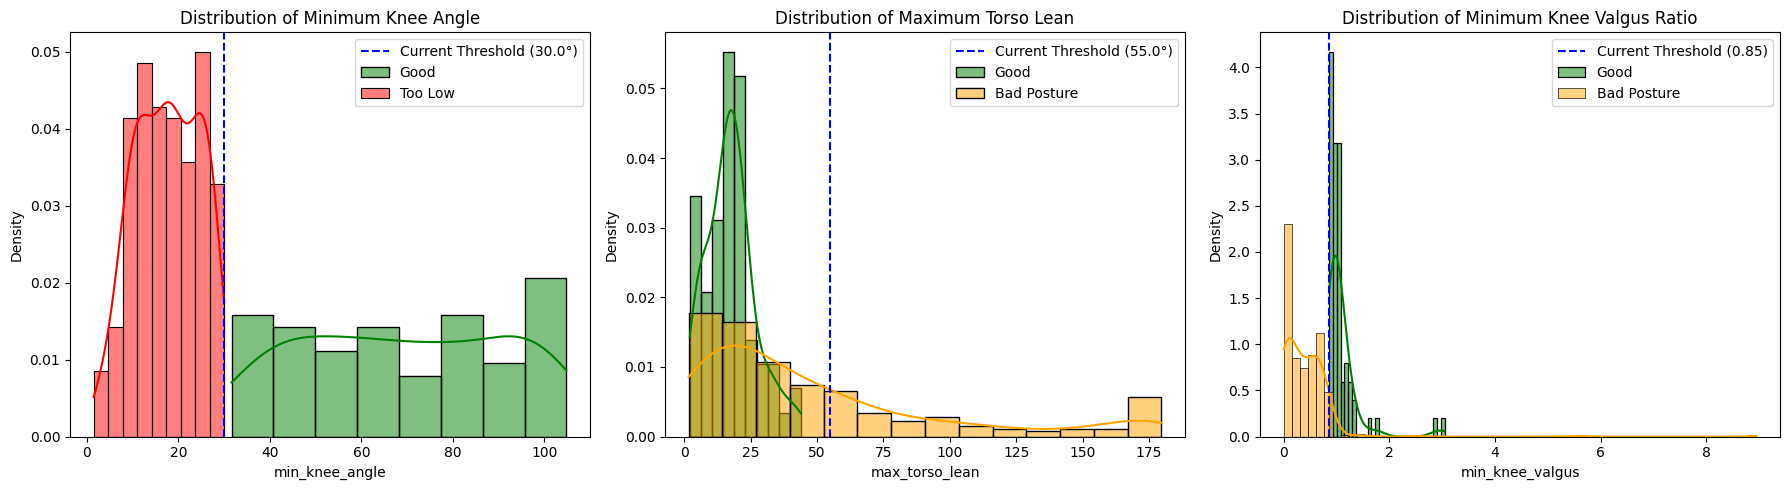

In [ ]:

if 'rep_df' in locals() and not rep_df.empty:
    rep_df['min_knee_angle'] = rep_df[['min_left_knee', 'min_right_knee']].min(axis=1)
    
    print("--- Summary Statistics by Label ---")
    diagnostic_features = ['min_knee_angle', 'max_torso_lean', 'min_knee_valgus']
    stats = rep_df.groupby('label')[diagnostic_features].agg(['mean', 'std', 'min', 'max'])
    display(stats)

    print("\n--- Feature Distribution Plots ---")
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(data=rep_df[rep_df['label'] == 'good'], x='min_knee_angle', color='green', label='Good', kde=True, stat="density", common_norm=False)
    sns.histplot(data=rep_df[rep_df['label'] == 'too_low'], x='min_knee_angle', color='red', label='Too Low', kde=True, stat="density", common_norm=False)
    plt.axvline(x=SquatAdvisor.GOOD_KNEE_ANGLE_MIN, color='blue', linestyle='--', label=f'Current Threshold ({SquatAdvisor.GOOD_KNEE_ANGLE_MIN}°)')
    plt.title('Distribution of Minimum Knee Angle')
    plt.legend()
    plt.subplot(1, 3, 2)
    sns.histplot(data=rep_df[rep_df['label'] == 'good'], x='max_torso_lean', color='green', label='Good', kde=True, stat="density", common_norm=False)
    sns.histplot(data=rep_df[rep_df['label'] == 'bad_posture'], x='max_torso_lean', color='orange', label='Bad Posture', kde=True, stat="density", common_norm=False)
    plt.axvline(x=SquatAdvisor.MAX_TORSO_LEAN_DEGREES, color='blue', linestyle='--', label=f'Current Threshold ({SquatAdvisor.MAX_TORSO_LEAN_DEGREES}°)')
    plt.title('Distribution of Maximum Torso Lean')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    sns.histplot(data=rep_df[rep_df['label'] == 'good'], x='min_knee_valgus', color='green', label='Good', kde=True, stat="density", common_norm=False)
    sns.histplot(data=rep_df[rep_df['label'] == 'bad_posture'], x='min_knee_valgus', color='orange', label='Bad Posture', kde=True, stat="density", common_norm=False)
    plt.axvline(x=SquatAdvisor.MIN_KNEE_VALGUS_RATIO, color='blue', linestyle='--', label=f'Current Threshold ({SquatAdvisor.MIN_KNEE_VALGUS_RATIO})')
    plt.title('Distribution of Minimum Knee Valgus Ratio')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("rep_df not found or is empty. Please run the auto-labeling cell first.")



Original training set size: 494
New SMOTE-balanced training set size: 873
Test set size: 213

--- Tuning RandomForest ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Tuning finished in 2.76 seconds.
Best Score for RandomForest on validation set: 0.9885

--- Tuning XGBoost ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:42:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_

Tuning finished in 1.26 seconds.
Best Score for XGBoost on validation set: 0.9885

--- Final Evaluation on Unseen Test Set ---
Accuracy for tuned RandomForest: 0.9906
Accuracy for tuned XGBoost: 0.9859

--- Best Overall Model: RandomForest with score 0.9906 ---

Classification Report:
               precision    recall  f1-score   support

 bad_posture       1.00      0.98      0.99       126
        good       1.00      1.00      1.00        21
     too_low       0.97      1.00      0.99        66

    accuracy                           0.99       213
   macro avg       0.99      0.99      0.99       213
weighted avg       0.99      0.99      0.99       213



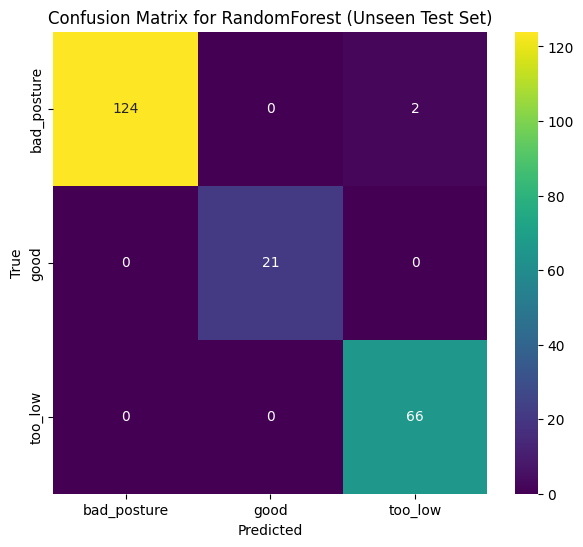

Saved best auto-labeled model to models/squat_quality_multiclass_auto.joblib

Macro-Average ROC AUC Score: 1.0000


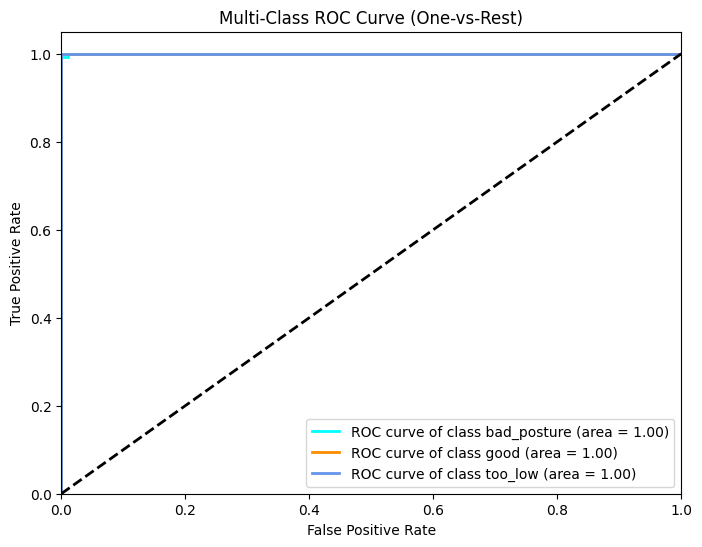

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import time
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except (ImportError, xgb.XGBoostError):
    print("XGBoost not found or failed to load. The model tournament will only include RandomForest.")
    XGBOOST_AVAILABLE = False

if not rep_df.empty and len(rep_df['label'].unique()) > 1:
    X_full = rep_df[SQUAT_REP_FEATURES].values.astype(np.float32)
    y_full_str = rep_df['label'].values
    
    le = LabelEncoder()
    y_full = le.fit_transform(y_full_str)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.3, random_state=42, stratify=y_full if len(set(y_full)) > 1 else None
    )

    print(f"Original training set size: {len(X_train)}")
    min_class_count = pd.Series(y_train).value_counts().min()
    k_neighbors = min(3, min_class_count - 1) if min_class_count > 1 else 1
    
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print(f"New SMOTE-balanced training set size: {len(X_train_smote)}")
    print(f"Test set size: {len(X_test)}")

    models_to_tune = {
        "RandomForest": {
            "model": RandomForestClassifier(random_state=42),
            "params": {'n_estimators': [100, 200], 'max_depth': [10, 20]}
        }
    }
    if XGBOOST_AVAILABLE:
        models_to_tune["XGBoost"] = {
            "model": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
            "params": {'n_estimators': [100, 200], 'max_depth': [5, 7], 'learning_rate': [0.1, 0.2]}
        }

    best_estimators = {}
    for name, config in models_to_tune.items():
        print(f"\n--- Tuning {name} ---")
        start_time = time.time()
        grid_search = GridSearchCV(config["model"], config["params"], cv=3, n_jobs=-1, scoring='accuracy', verbose=1)
        grid_search.fit(X_train_smote, y_train_smote)
        print(f"Tuning finished in {time.time() - start_time:.2f} seconds.")
        best_estimators[name] = grid_search.best_estimator_
        print(f"Best Score for {name} on validation set: {grid_search.best_score_:.4f}")

    best_model_name, best_model, best_score = "None", None, 0.0
    print("\n--- Final Evaluation on Unseen Test Set ---")
    for name, estimator in best_estimators.items():
        score = estimator.score(X_test, y_test)
        print(f"Accuracy for tuned {name}: {score:.4f}")
        if score > best_score:
            best_score, best_model, best_model_name = score, estimator, name
            
    print(f"\n--- Best Overall Model: {best_model_name} with score {best_score:.4f} ---")
    if best_model:
        y_pred = best_model.predict(X_test)
        class_names = le.classes_
        print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='viridis')
        plt.title(f'Confusion Matrix for {best_model_name} (Unseen Test Set)')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        
        Path('models').mkdir(exist_ok=True)
        joblib.dump(best_model, 'models/squat_quality_multiclass_auto.joblib')
        print("Saved best auto-labeled model to models/squat_quality_multiclass_auto.joblib")

        if hasattr(best_model, "predict_proba"):
            from sklearn.metrics import roc_curve, auc
            from sklearn.preprocessing import label_binarize
            from itertools import cycle

            y_score = best_model.predict_proba(X_test)
            y_test_binarized = label_binarize(y_test, classes=np.arange(len(class_names)))
            n_classes = y_test_binarized.shape[1]

            fpr = dict()
            tpr = dict()
            roc_auc = dict()

            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])

            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= n_classes
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

            print(f"\nMacro-Average ROC AUC Score: {roc_auc['macro']:.4f}")

            plt.figure(figsize=(8, 6))
            colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
            for i, color in zip(range(n_classes), colors):
                plt.plot(fpr[i], tpr[i], color=color, lw=2,
                         label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')
            
            plt.plot([0, 1], [0, 1], 'k--', lw=2)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Multi-Class ROC Curve (One-vs-Rest)')
            plt.legend(loc="lower right")
            plt.show()

else:
    print("No reps extracted; skipping squat model training.")



### Model Interpretation: Feature Importance



In [ ]:
if 'best_estimators' in locals() and best_estimators:
    num_models = len(best_estimators)
    fig, axes = plt.subplots(1, num_models, figsize=(8 * num_models, 8), squeeze=False)
    
    axes = axes.flatten()

    for i, (name, model) in enumerate(best_estimators.items()):
        if hasattr(model, 'feature_importances_'):
            importances = pd.Series(model.feature_importances_, index=SQUAT_REP_FEATURES).sort_values()
            ax = axes[i]
            importances.plot(kind='barh', ax=ax)
            ax.set_title(f'Feature Importance for {name}')
            ax.set_xlabel('Importance')
            
    plt.tight_layout()
    plt.show()

else:
    print("Best estimators not found. Please run the model training cell above.")



### Evaluation Visualizations




/var/folders/hb/vm3f20gj20b9csml0d9k_wxr0000gn/T/ipykernel_3276/1773645979.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette='viridis')


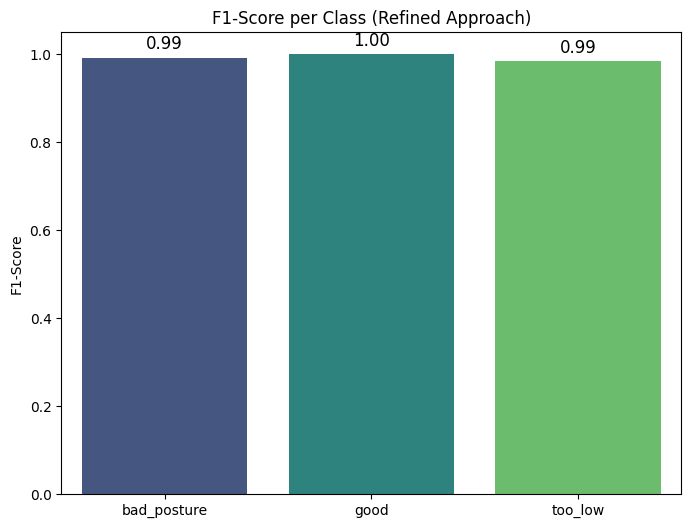

In [ ]:
if 'best_model' in locals():
    if 'y_pred' not in locals():
        y_pred = best_model.predict(X_test)
        
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    
    f1_scores = {label: report[label]['f1-score'] for label in class_names}
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette='viridis')
    plt.title('F1-Score per Class (Refined Approach)')
    plt.ylabel('F1-Score')
    plt.ylim(0, 1.05)
    
    for index, value in enumerate(f1_scores.values()):
        plt.text(index, value + 0.01, f"{value:.2f}", ha='center', va='bottom', fontsize=12)
        
    plt.show()
else:
    print("Model not trained. Please run the main training and evaluation cell first.")


In [ ]:
if not rep_df.empty:
    print("\\n--- Diagnostic Info: Full Label Distribution ---")
    print(rep_df['refined_label'].value_counts())
    print("\\n--- Diagnostic Info: DataFrame Head ---")
    print(rep_df.head())
else:
    print("DataFrame is empty. No reps were extracted.")

\n--- Diagnostic Info: Full Label Distribution ---
refined_label
Good           223
Bad Posture    208
Too Low         49
Name: count, dtype: int64
\n--- Diagnostic Info: DataFrame Head ---
   min_left_knee  min_right_knee  max_left_knee  max_right_knee    rom_left  \
0      38.527546       49.410309     152.150269      163.531616  113.622726   
1      94.223488      117.166161     159.982071      165.336456   65.758575   
2      74.879753       68.188896     150.063950      150.366592   75.184196   
3     102.324120       92.778778     150.481171      162.032944   48.157047   
4      89.280815       79.886391     151.346497      157.748795   62.065681   

    rom_right  avg_torso_lean  max_torso_lean  std_torso_lean  avg_knee_angle  \
0  114.121307       10.362903       11.503435        0.568078       74.668312   
1   48.170296        9.733435       11.317871        1.725380      111.633408   
2   82.177696       31.323912       35.532913        5.013528      107.421982   
3   69.2541

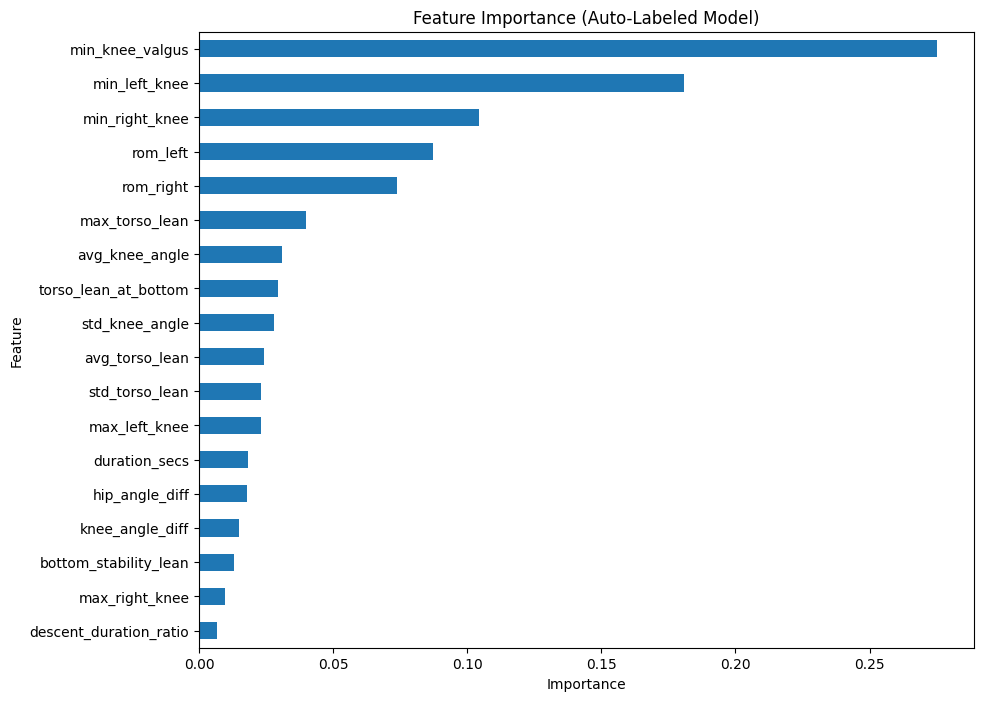

In [ ]:
if 'clf' in locals() and hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    
    plt.figure(figsize=(10, 8))
    feat_series = pd.Series(importances, index=SQUAT_REP_FEATURES).sort_values()
    feat_series.plot(kind='barh')
    plt.title('Feature Importance (Auto-Labeled Model)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print("Classifier 'clf' not found or does not have feature importances. Please run the training cell above.")



### Train and Evaluate Exercise Classifier (High-Level)


In [ ]:
CACHE_PATH = Path('outputs/exercise_df_cache.pkl')
REPROCESS_VIDEOS = False 

if not REPROCESS_VIDEOS and CACHE_PATH.exists():
    print(f"Loading cached exercise data from {CACHE_PATH}")
    exercise_df = pd.read_pickle(CACHE_PATH)
else:
    print("Processing videos to create new exercise dataframe...")
    VELOCITY_FEATURE_ORDER = FEATURE_ORDER + [f"{feat}_v" for feat in FEATURE_ORDER]
    exercise_rows = []
    exercise_folders = [f.name for f in Path(kaggle_path).iterdir() if f.is_dir()]
    pose = PoseEstimator()
    for exercise_name in exercise_folders:
        exercise_dir = Path(kaggle_path) / exercise_name
        videos = [p for p in exercise_dir.rglob('*') if p.suffix.lower() in VIDEO_EXTS]
        for vf in tqdm(videos, desc=f"Processing {exercise_name}"):
            cap = cv2.VideoCapture(str(vf))
            if not cap.isOpened(): continue
            last_features = deque(maxlen=2)
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                results, _ = pose.process(frame)
                if results and results.pose_landmarks:
                    lms = results.pose_landmarks.landmark
                    current_features = extract_feature_vector(lms)
                    if len(last_features) == 2:
                        velocity_features = current_features - last_features[0]
                        combined_features = np.concatenate([current_features, velocity_features])
                        row = {VELOCITY_FEATURE_ORDER[i]: v for i, v in enumerate(combined_features)}
                        row['label'] = exercise_name
                        exercise_rows.append(row)
                    last_features.append(current_features)
            cap.release()
    pose.close()
    exercise_df = pd.DataFrame(exercise_rows)
    exercise_df.to_pickle(CACHE_PATH)
    print(f"Saved exercise data to cache: {CACHE_PATH}")

print(f"\nExtracted {len(exercise_df)} frames for exercise classification.")
print("Label distribution:\n", exercise_df['label'].value_counts())



Loading cached exercise data from outputs/exercise_df_cache.pkl

Extracted 140247 frames for exercise classification.
Label distribution:
 label
plank                  9835
push-up                9758
squat                  8447
lateral raise          8282
tricep dips            7294
t bar row              7159
incline bench press    6699
barbell biceps curl    6686
pull Up                6612
lat pulldown           5967
hip thrust             5787
romanian deadlift      5733
tricep Pushdown        5609
leg extension          5498
russian twist          5421
hammer curl            5413
leg raises             5345
bench press            5160
shoulder press         5133
deadlift               5032
chest fly machine      5001
decline bench press    4376
Name: count, dtype: int64


/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(



--- Tuning RandomForest ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Tuning finished in 574.90 seconds.
Best Score for RandomForest: 0.9309

--- Tuning XGBoost ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:34:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:34:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:34:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/user/MScAI_Thesis/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [16:34:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_

Tuning finished in 265.52 seconds.
Best Score for XGBoost: 0.9232

--- Best Overall Model: RandomForest with score 0.8905 ---

Classification Report:
                      precision    recall  f1-score   support

barbell biceps curl       0.86      0.84      0.85      1337
        bench press       0.78      0.80      0.79      1032
  chest fly machine       0.94      0.92      0.93      1000
           deadlift       0.93      0.91      0.92      1006
decline bench press       0.88      0.88      0.88       875
        hammer curl       0.85      0.84      0.84      1083
         hip thrust       0.95      0.90      0.92      1157
incline bench press       0.87      0.86      0.86      1340
       lat pulldown       0.88      0.82      0.85      1193
      lateral raise       0.86      0.89      0.87      1656
      leg extension       0.92      0.92      0.92      1100
         leg raises       0.87      0.92      0.89      1069
              plank       0.99      0.99      0.99     

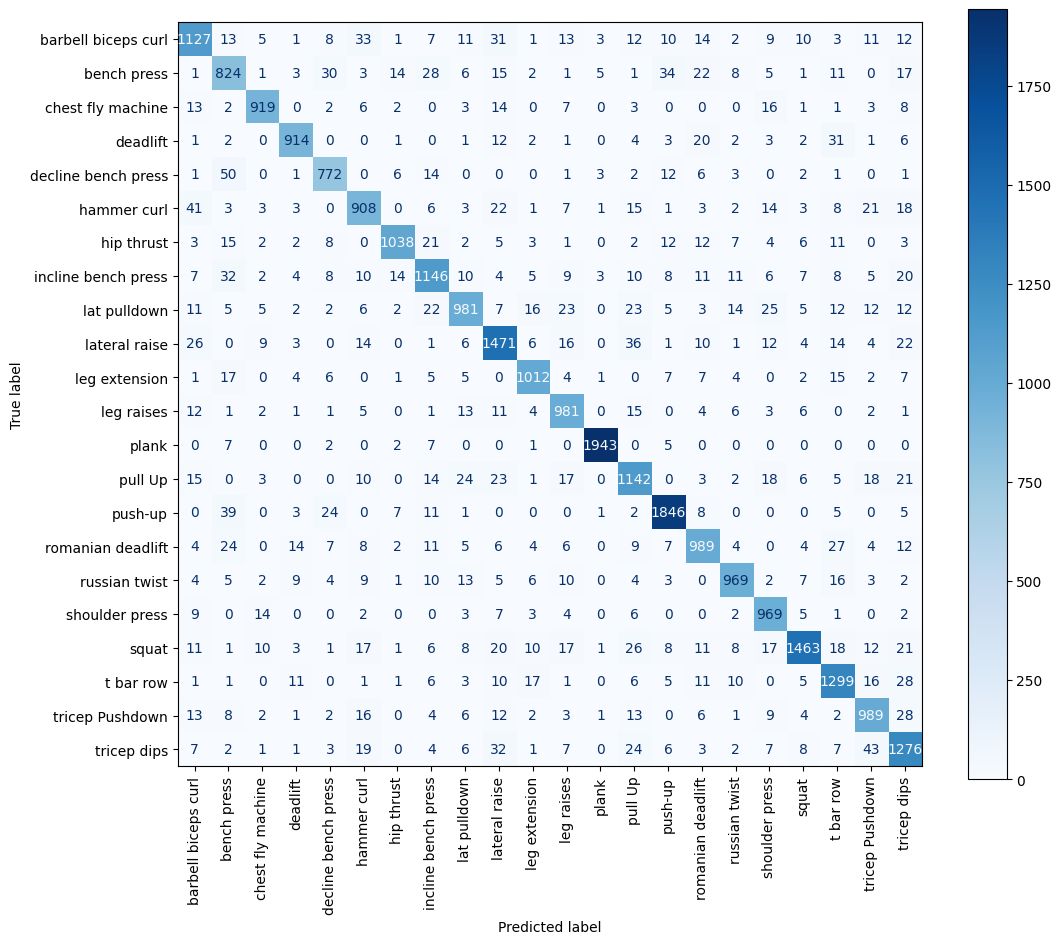


Best model and label encoder saved.


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
import time
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except (ImportError, xgb.XGBoostError):
    XGBOOST_AVAILABLE = False

if not exercise_df.empty:
    VELOCITY_FEATURE_ORDER = FEATURE_ORDER + [f"{feat}_v" for feat in FEATURE_ORDER]
    X = exercise_df[VELOCITY_FEATURE_ORDER].values.astype(np.float32)
    y_str = exercise_df['label'].values
    le = LabelEncoder()
    y = le.fit_transform(y_str)
    class_names = le.classes_
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    min_class_count = pd.Series(y_train).value_counts().min()
    k_neighbors = min(3, min_class_count - 1) if min_class_count > 1 else 1
    smote = SMOTE(random_state=42, n_jobs=-1, k_neighbors=k_neighbors)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    models_to_tune = {
        "RandomForest": {"model": RandomForestClassifier(random_state=42), "params": {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}}
    }
    if XGBOOST_AVAILABLE:
        models_to_tune["XGBoost"] = {"model": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'), "params": {'n_estimators': [100, 200], 'max_depth': [5, 7], 'learning_rate': [0.1, 0.2]}}

    best_estimators = {}
    for name, config in models_to_tune.items():
        print(f"\n--- Tuning {name} ---")
        start_time = time.time()
        grid_search = GridSearchCV(config["model"], config["params"], cv=3, n_jobs=-1, scoring='accuracy', verbose=1)
        grid_search.fit(X_train_smote, y_train_smote)
        print(f"Tuning finished in {time.time() - start_time:.2f} seconds.")
        best_estimators[name] = grid_search.best_estimator_
        print(f"Best Score for {name}: {grid_search.best_score_:.4f}")

    best_model_name, best_model, best_score = "None", None, 0.0
    for name, estimator in best_estimators.items():
        score = estimator.score(X_test, y_test)
        if score > best_score:
            best_score, best_model, best_model_name = score, estimator, name
    
    print(f"\n--- Best Overall Model: {best_model_name} with score {best_score:.4f} ---")
    if best_model:
        y_pred = best_model.predict(X_test)
        print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
        fig, ax = plt.subplots(figsize=(12, 10))
        ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax, cmap='Blues', display_labels=class_names, xticks_rotation='vertical')
        plt.show()
        joblib.dump(best_model, "models/exercise_classifier_best.joblib")
        joblib.dump(le, "models/exercise_label_encoder.joblib")
        print("\nBest model and label encoder saved.")
else:
    print("Exercise dataframe is empty. Cannot train model.")



Found 3 videos to process in 'test_video'.

--- Processing: squat_8.mp4 ---


I0000 00:00:1755610677.004394   17035 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1755610677.138642  798259 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755610677.160842  798259 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Saved to: outputs/hybrid_auto_squat_8.mp4

--- Processing: videoplayback (1).mov ---


I0000 00:00:1755610679.929685   17035 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1755610680.011970  798369 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755610680.028620  798369 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Saved to: outputs/hybrid_auto_videoplayback (1).mp4

--- Processing: videoplayback.mov ---


I0000 00:00:1755610717.819746   17035 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1755610717.952708  799306 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1755610717.977008  799306 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Saved to: outputs/hybrid_auto_videoplayback.mp4


--- Inference Previews ---

Preview for: squat_8.mp4


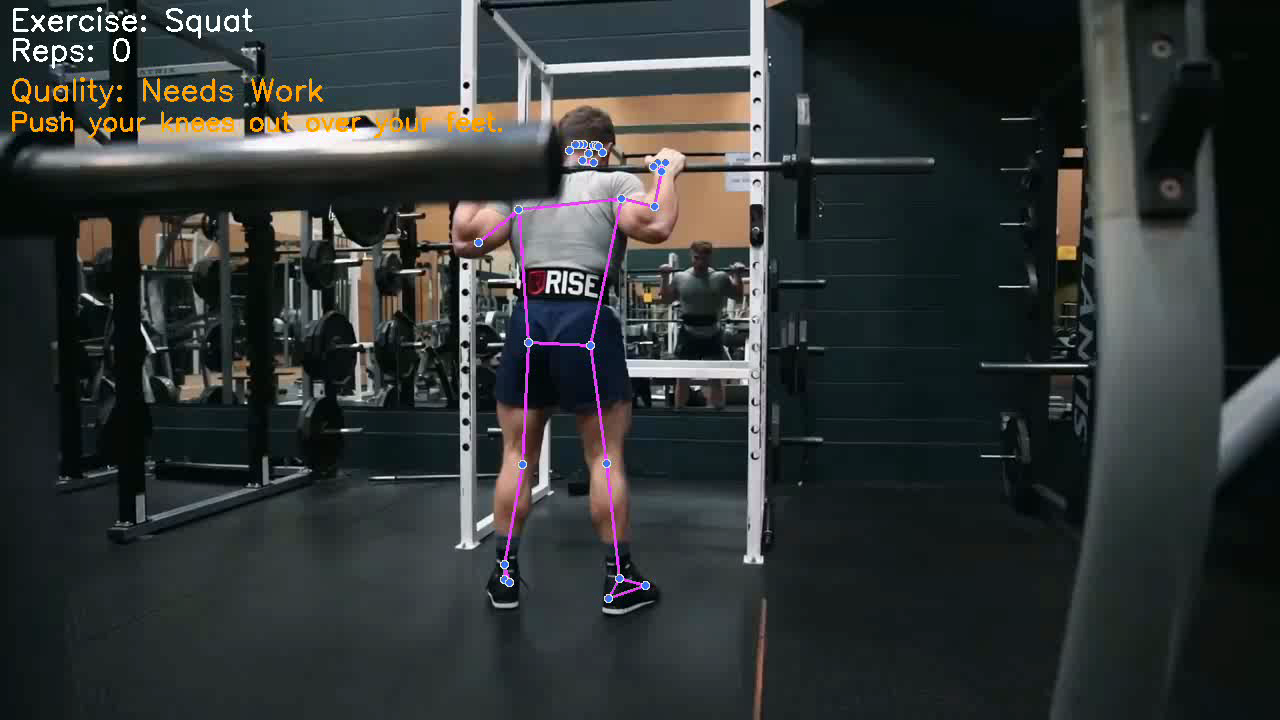


Preview for: videoplayback (1).mov


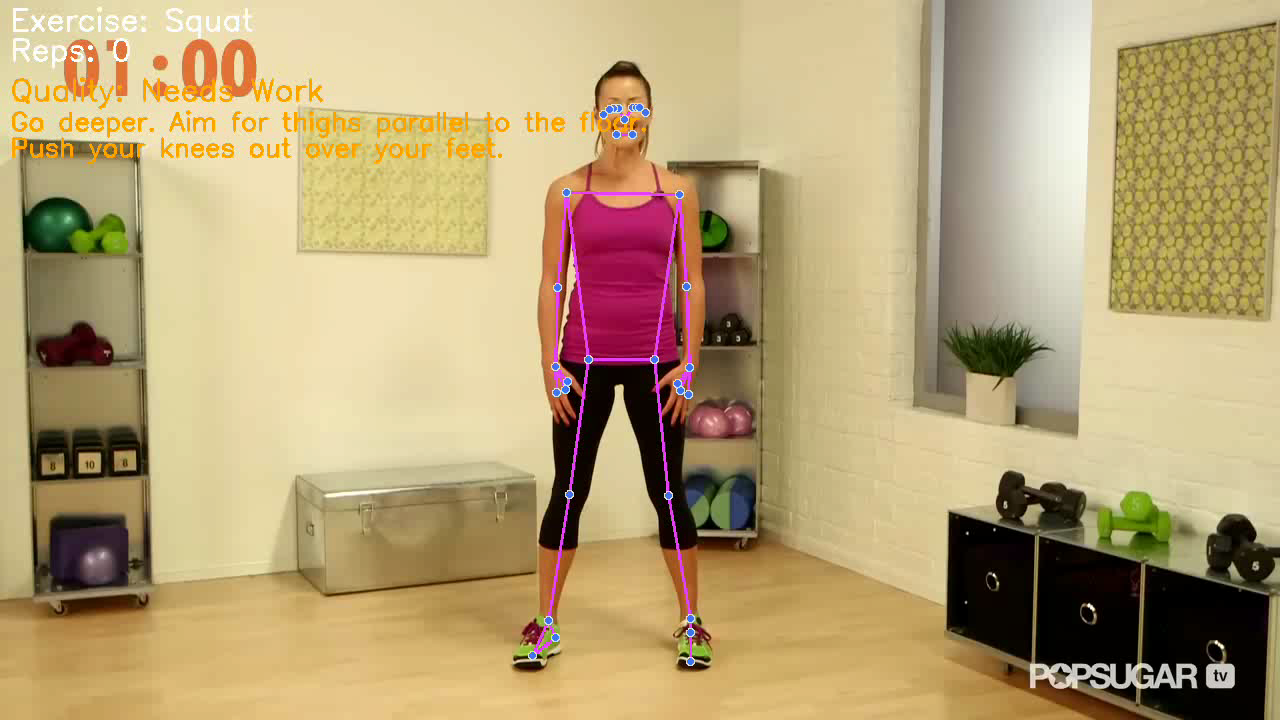


Preview for: videoplayback.mov


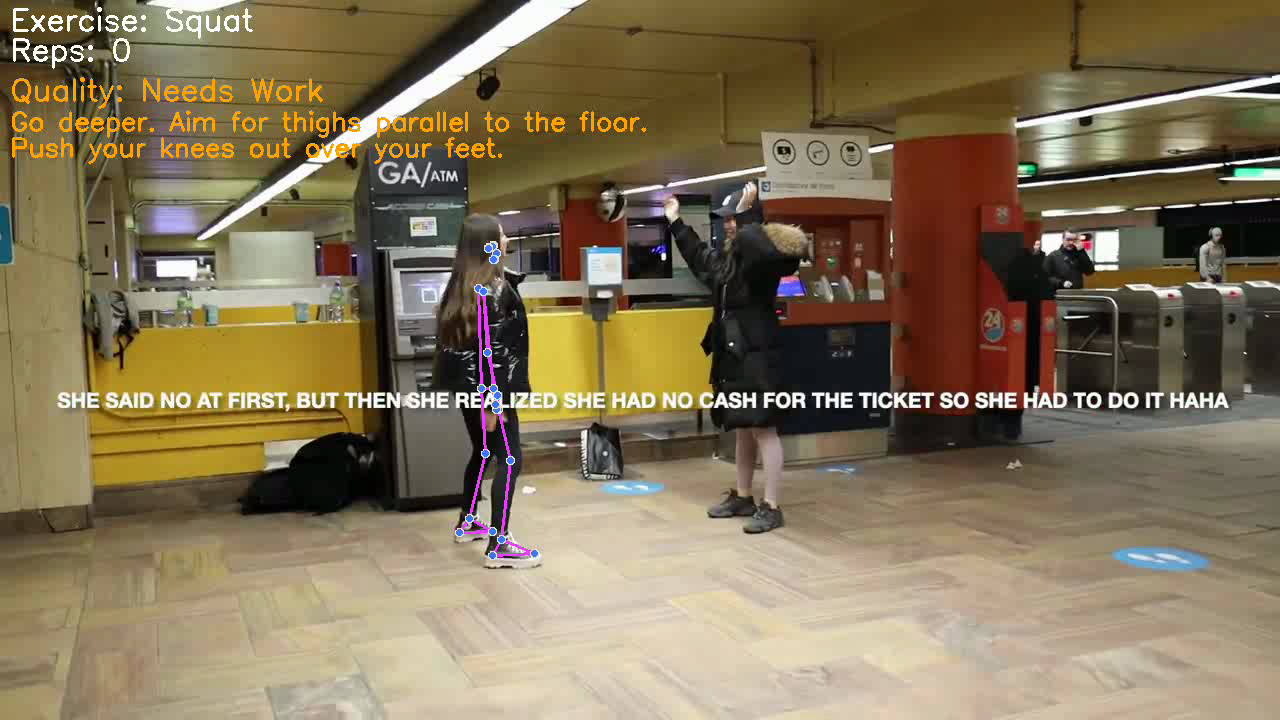

In [ ]:

def ensure_even_size(w, h):
    return (w - (w % 2), h - (w % 2))

local_test = Path('test_video')
all_videos = [p for p in local_test.rglob('*') if p.suffix.lower() in VIDEO_EXTS]
assert all_videos, f'No videos found in {local_test}.'

print(f"Found {len(all_videos)} videos to process in '{local_test}'.")
all_previews = []

for sample in all_videos:
    print('\n--- Processing:', sample.name, '---')
    cap = cv2.VideoCapture(str(sample))
    if not cap.isOpened(): continue
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w, h = ensure_even_size(w, h)
    out_dir = Path('outputs'); out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'hybrid_auto_{sample.stem}.mp4'
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    coach = HybridSquatCoach(model_path='models/squat_quality_multiclass_auto.joblib')
    
    pose = PoseEstimator()
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_LINEAR)
        results_pose, image = pose.process(frame)
        if results_pose.pose_landmarks is None:
            if writer: writer.write(image)
            continue
        ui = coach.update(results_pose.pose_landmarks.landmark)
        cv2.putText(image, f'Exercise: Squat', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        cv2.putText(image, f'Reps: {ui["rep_count"]}', (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)
        cv2.putText(image, ui["display_quality"], (10, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, ui["display_color"], 2)
        y0 = 130
        for rec in ui["display_recs"]:
            cv2.putText(image, rec, (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.85, ui["display_color"], 2)
            y0 += 26
        PoseEstimator.draw_landmarks(image, results_pose.pose_landmarks)
        if writer: writer.write(image)
    
    pose.close()
    cap.release()
    if writer: writer.release()
    print('Saved to:', out_path)
    
    cap = cv2.VideoCapture(str(out_path))
    ret, frame = cap.read()
    if ret:
        all_previews.append((sample.name, Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))))
    cap.release()

print("\n\n--- Inference Previews ---")
for name, img in all_previews:
    print(f"\nPreview for: {name}")
    display(img)

